# Projet Data Mining - Détection d'Intrusions Réseau

## Partie : Model Building, Evaluation & Discussion of Results

**Auteur** : Majda Bendifi  
**Encadrante** : Pr. EL ASRI Ikram  
**Date** : Mars 2026  

---

## Objectif de la partie

Cette partie du projet Data Mining se concentre sur trois phases clés :

### 1. Model Building (Construction des modèles)
- Implémentation de deux algorithmes de classification :
  - **Régression Logistique** : modèle linéaire, interprétable
  - **Random Forest** : modèle ensembliste, non linéaire
- Utilisation des données préparées par mon collègue
- Justification technique des choix algorithmiques

### 2. Model Evaluation (Évaluation des performances)
- Métriques adaptées à la détection d'intrusions :
  - **Accuracy** : Pourcentage de bonnes classifications
  - **Precision** : Exactitude des détections d'attaques
  - **Recall** : Capacité à détecter toutes les attaques
  - **F1-score** : Équilibre précision/rappel
  - **AUC-ROC** : Capacité de discrimination
- Visualisation : Matrices de confusion
- Validation : Cross-validation pour robustesse

### 3. Discussion of Results (Analyse et interprétation)
- Comparaison objective des deux modèles
- Identification du meilleur modèle et justification
- Analyse des forces et faiblesses de chaque approche
- Limitations du projet
- Propositions d'améliorations

---

## Contexte métier

- **Dataset** : KDD Cup 99 / NSL-KDD
  - Référence internationale en détection d'intrusions
  - Total : 23 classes distinctes (normaux + différents types d'attaques)

- **Problématique** : Classification binaire (normal vs attaque)
  - Normal : Trafic réseau légitime
  - Attaque : Comportement malveillant (DoS, Probe, R2L, U2R)

- **Données d'entrée** : dossier `data_prepared/`
  - `X_train_prepared.csv` : Features d'entraînement
  - `X_test_prepared.csv` : Features de test
  - `y_train.csv` : Labels d'entraînement
  - `y_test.csv` : Labels de test

# Projet Data Mining - Détection d'Intrusions Réseau

## Partie : Model Building, Evaluation & Discussion of Results

**Auteur** : Majda Bendifi  
**Encadrante** : Pr. EL ASRI Ikram  
**Date** : Mars 2026  

---

## Objectif de la partie

Cette partie du projet Data Mining se concentre sur trois phases clés :

### 1. Model Building (Construction des modèles)
- Implémentation de deux algorithmes de classification :
  - **Régression Logistique** : modèle linéaire, interprétable
  - **Random Forest** : modèle ensembliste, non linéaire
- Utilisation des données préparées par mon collègue
- Justification technique des choix algorithmiques

### 2. Model Evaluation (Évaluation des performances)
- Métriques adaptées à la détection d'intrusions :
  - **Accuracy** : Pourcentage de bonnes classifications
  - **Precision** : Exactitude des détections d'attaques
  - **Recall** : Capacité à détecter toutes les attaques
  - **F1-score** : Équilibre précision/rappel
  - **AUC-ROC** : Capacité de discrimination
- Visualisation : Matrices de confusion
- Validation : Cross-validation pour robustesse

### 3. Discussion of Results (Analyse et interprétation)
- Comparaison objective des deux modèles
- Identification du meilleur modèle et justification
- Analyse des forces et faiblesses de chaque approche
- Limitations du projet
- Propositions d'améliorations

---

## Contexte métier

- **Dataset** : KDD Cup 99 / NSL-KDD
  - Référence internationale en détection d'intrusions
  - Total : 23 classes distinctes (normaux + différents types d'attaques)

- **Problématique** : Classification binaire (normal vs attaque)
  - Normal : Trafic réseau légitime
  - Attaque : Comportement malveillant (DoS, Probe, R2L, U2R)

- **Données d'entrée** : dossier `data_prepared/`
  - `X_train_prepared.csv` : Features d'entraînement
  - `X_test_prepared.csv` : Features de test
  - `y_train.csv` : Labels d'entraînement
  - `y_test.csv` : Labels de test

## Import des bibliothèques nécessaires

In [5]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Bibliothèques importées avec succès!")

✅ Bibliothèques importées avec succès!


## Chargement des données préparées

In [8]:
import os

# Chemin vers data_prepared
data_path = "/Users/macair/Downloads/data_prepared/"

# Vérifier que le dossier existe
if os.path.exists(data_path):
    print(f"✅ Dossier trouvé : {data_path}")
    print(f"📁 Contenu : {os.listdir(data_path)}")
else:
    print("❌ Dossier non trouvé!")

# Charger UNIQUEMENT les fichiers CSV (données prêtes pour la modélisation)
print("\n" + "="*50)
print("📊 CHARGEMENT DES DONNÉES")
print("="*50)

X_train = pd.read_csv(data_path + "X_train_prepared.csv")
X_test = pd.read_csv(data_path + "X_test_prepared.csv")
y_train = pd.read_csv(data_path + "y_train.csv").values.ravel()
y_test = pd.read_csv(data_path + "y_test.csv").values.ravel()

# Charger le mapping des attaques (optionnel, pour interprétation)
attack_mapping = None
if os.path.exists(data_path + "attack_mapping.json"):
    with open(data_path + "attack_mapping.json", 'r') as f:
        attack_mapping = json.load(f)
    print("✅ Attack mapping chargé")

print("\n✅ Données chargées avec succès!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")

# Afficher les premières lignes pour vérification
print("\n📋 Aperçu de X_train (5 premières lignes):")
print(X_train.head())

print("\n📋 Aperçu de y_train (premières valeurs):")
print(y_train[:10])

# Distribution des classes
print("\n🎯 Distribution des classes dans y_train:")
print(pd.Series(y_train).value_counts())

# Vérifier le type de classification (binaire ou multi-classe)
unique_classes = np.unique(y_train)
print(f"\n🎯 Nombre de classes uniques: {len(unique_classes)}")
if len(unique_classes) == 2:
    print("   → Classification BINAIRE (normal vs attaque)")
else:
    print(f"   → Classification MULTI-CLASSES ({len(unique_classes)} classes)")
    if attack_mapping:
        print("   Mapping des classes:", attack_mapping)

✅ Dossier trouvé : /Users/macair/Downloads/data_prepared/
📁 Contenu : ['X_train_prepared.csv', 'scaler.pkl', 'X_test_prepared.csv', 'attack_mapping.json', 'y_train.csv', 'y_test.csv', 'label_encoder_flag.pkl', 'label_encoder_service.pkl']

📊 CHARGEMENT DES DONNÉES
✅ Attack mapping chargé

✅ Données chargées avec succès!
   X_train: (34545, 43)
   X_test: (8637, 43)
   y_train: (34545,)
   y_test: (8637,)

📋 Aperçu de X_train (5 premières lignes):
   wrong_fragment    urgent      hot  num_failed_logins  num_compromised  \
0       -0.084394 -0.004737 -0.07021          -0.018022        -0.007905   
1       -0.084394 -0.004737 -0.07021          -0.018022        -0.007905   
2       -0.084394 -0.004737 -0.07021          -0.018022        -0.007905   
3       -0.084394 -0.004737 -0.07021          -0.018022        -0.007905   
4       -0.084394 -0.004737 -0.07021          -0.018022        -0.007905   

   root_shell  su_attempted  num_root  num_file_creations  num_shells  ...  \
0    -0.01944 

## Model Building - Construction des modèles

In [9]:
# Modèle 1: Régression Logistique
logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

# Modèle 2: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

print("✅ Modèles initialisés")

✅ Modèles initialisés


## Entraînement

In [10]:
# Entraînement
print("Entraînement de la Régression Logistique...")
logreg_model.fit(X_train, y_train)

print("Entraînement du Random Forest...")
rf_model.fit(X_train, y_train)

print("✅ Entraînement terminé!")

Entraînement de la Régression Logistique...
Entraînement du Random Forest...
✅ Entraînement terminé!


## Model Evaluation - Évaluation des performances

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)

# Fonction d'évaluation pour multi-classes
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    
    print(f"\n{'='*60}")
    print(f"📊 {model_name}")
    print(f"{'='*60}")
    
    # Métriques pour multi-classes
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"✅ Accuracy  : {accuracy:.4f}")
    print(f"✅ Precision : {precision:.4f} (weighted)")
    print(f"✅ Recall    : {recall:.4f} (weighted)")
    print(f"✅ F1-Score  : {f1:.4f} (weighted)")
    
    return y_pred, f1, accuracy, precision, recall

# Évaluation des modèles
print("\n" + "="*60)
print("🔍 ÉVALUATION DES MODÈLES")
print("="*60)

# Évaluer la Régression Logistique
y_pred_logreg, f1_logreg, acc_logreg, prec_logreg, rec_logreg = evaluate_model(
    logreg_model, X_test, y_test, "Régression Logistique"
)

# Évaluer le Random Forest
y_pred_rf, f1_rf, acc_rf, prec_rf, rec_rf = evaluate_model(
    rf_model, X_test, y_test, "Random Forest"
)

print("\n✅ Évaluation terminée!")


🔍 ÉVALUATION DES MODÈLES

📊 Régression Logistique
✅ Accuracy  : 0.9774
✅ Precision : 0.9827 (weighted)
✅ Recall    : 0.9774 (weighted)
✅ F1-Score  : 0.9792 (weighted)

📊 Random Forest
✅ Accuracy  : 0.9978
✅ Precision : 0.9978 (weighted)
✅ Recall    : 0.9978 (weighted)
✅ F1-Score  : 0.9978 (weighted)

✅ Évaluation terminée!


### Comparaison 


📊 COMPARAISON DES MODÈLES
               Modèle  Accuracy  Precision   Recall  F1-Score
Régression Logistique  0.977423   0.982723 0.977423  0.979209
        Random Forest  0.997800   0.997788 0.997800  0.997769


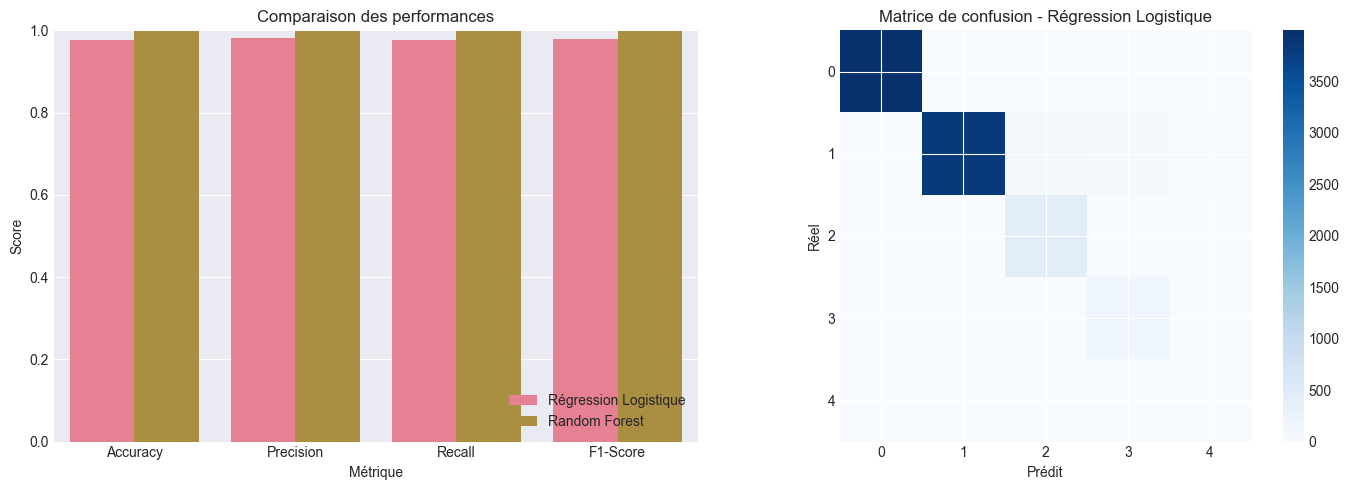

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*70)
print("📊 COMPARAISON DES MODÈLES")
print("="*70)

# Créer le tableau de comparaison
comparison = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest'],
    'Accuracy': [acc_logreg, acc_rf],
    'Precision': [prec_logreg, prec_rf],
    'Recall': [rec_logreg, rec_rf],
    'F1-Score': [f1_logreg, f1_rf]
})

print(comparison.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1: Barres comparatives
comparison_melted = comparison.melt(id_vars=['Modèle'], var_name='Métrique', value_name='Score')
sns.barplot(data=comparison_melted, x='Métrique', y='Score', hue='Modèle', ax=axes[0])
axes[0].set_title('Comparaison des performances')
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right')

# Graphique 2: Matrices de confusion
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Heatmap pour Régression Logistique
im1 = axes[1].imshow(cm_logreg, cmap='Blues')
axes[1].set_title('Matrice de confusion - Régression Logistique')
axes[1].set_xlabel('Prédit')
axes[1].set_ylabel('Réel')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()